# MuViS-C Quickstart

This notebook demonstrates the basic usage of the `muvis_c` package for
evaluating virtual sensor robustness against sensor failures.

We will:
1. Create a `Testbed` with a dataset
2. Add built-in failure modes
3. Register a simple model
4. Run the severity sweep
5. Inspect results with `summary()` and `plot_degradation()`

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
import muvis_c as rob

## 1. Prepare Data

The `Testbed` accepts a dataset as:
- A dataset ID string (resolved under `data_root`)
- A path to a directory with `train.ts` / `test.ts`
- A raw tuple `(X_train, y_train, X_test, y_test)` of numpy arrays

Here we use synthetic data for demonstration.

In [2]:
np.random.seed(42)
N_train, N_test, T, C = 200, 50, 20, 5

X_train = np.random.randn(N_train, T, C).astype(np.float32)
y_train = X_train[:, -1, 0] + 0.5 * X_train[:, -1, 1] + 0.1 * np.random.randn(N_train).astype(np.float32)

X_test = np.random.randn(N_test, T, C).astype(np.float32)
y_test = X_test[:, -1, 0] + 0.5 * X_test[:, -1, 1] + 0.1 * np.random.randn(N_test).astype(np.float32)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

Train: X=(200, 20, 5), y=(200,)
Test:  X=(50, 20, 5), y=(50,)


## 2. Create the Testbed

In [3]:
testbed = rob.Testbed(
    dataset=(X_train, y_train, X_test, y_test),
    severity_steps=10,
    k=3.0,
    seed=42,
    device="cpu",
)

## 3. Failure Modes

By default `Testbed()` uses all 10 built-in failure modes with the `k` passed to the constructor, so no extra setup is needed. To restrict to a specific subset, pass them to the constructor instead:

```python
from muvis_c.failures import BiasSeverity, NoiseSeverity
testbed = rob.Testbed(..., failures=[BiasSeverity(k=3.0), NoiseSeverity(k=3.0)])
```

Or exclude specific modes from the defaults:

```python
testbed = rob.Testbed(..., exclude_failures=[rob.Outliers])
```

## 4. Register Models

You can register models in three ways:
- `model=` — a sklearn-like object with `.predict()` or a PyTorch `nn.Module`
- `predict_fn=` — any callable `(X: ndarray) → ndarray`

In [4]:
# Train a simple linear regression
lr = LinearRegression()
lr.fit(X_train.reshape(N_train, -1), y_train)
testbed.add_model("LinearRegression", model=lr)

# Add a naive mean predictor via predict_fn
mean_val = y_train.mean()
testbed.add_model("MeanBaseline", predict_fn=lambda X: np.full(X.shape[0], mean_val))

In [5]:
testbed._models

{'LinearRegression': {'model': LinearRegression(), 'predict_fn': None},
 'MeanBaseline': {'model': None,
  'predict_fn': <function __main__.<lambda>(X)>}}

## 5. Run the Sweep

In [6]:
results = testbed.run()

Baseline RMSE: 1.3262  Bootstrap: 1.3284
custom | MeanBaseline (2/2): 100%|██████████| 1100/1100 [00:02<00:00, 471.40step/s, HardFaultSeverity [10/10] feat 5/5 RMSE=1.323]           


## 6. Inspect Results

In [7]:
# Print aggregated robustness scores
results.summary()


────────────────────────────────────────────────────────────────
 Dataset: custom
────────────────────────────────────────────────────────────────
 Model                 Nom. RMSE        mPC      rPC  s_cross
 ──────────────────── ────────── ────────── ──────── ────────
 LinearRegression         0.1508     0.4680    3.103    0.300
 MeanBaseline             1.3254     1.3254    1.000       --



In [8]:
# Raw per-severity data
results.raw.head(10)

,model,dataset,failure_mode,feature_idx,severity,k,rmse,baseline_rmse,baseline_boot_mean,clean_rmse,clean_boot_mean,clean_ci_lower,clean_ci_upper,boot_mean,ci_lower,ci_upper
0,LinearRegression,custom,BiasSeverity,0,0.0,3.0,0.151657,1.326156,1.328362,0.151657,0.150813,0.127874,0.178518,0.150813,0.127874,0.178518
1,LinearRegression,custom,BiasSeverity,0,0.1,3.0,0.281802,1.326156,1.328362,0.151657,0.150813,0.127874,0.178518,0.280999,0.246550,0.309301
2,LinearRegression,custom,BiasSeverity,0,0.2,3.0,0.550819,1.326156,1.328362,0.151657,0.150813,0.127874,0.178518,0.550250,0.512816,0.581915
3,LinearRegression,custom,BiasSeverity,0,0.3,3.0,0.833646,1.326156,1.328362,0.151657,0.150813,0.127874,0.178518,0.833201,0.794487,0.866352
4,LinearRegression,custom,BiasSeverity,0,0.4,3.0,1.119870,1.326156,1.328362,0.151657,0.150813,0.127874,0.178518,1.119491,1.080233,1.153293
5,LinearRegression,custom,BiasSeverity,0,0.5,3.0,1.407418,1.326156,1.328362,0.151657,0.150813,0.127874,0.178518,1.407081,1.367543,1.441242
6,LinearRegression,custom,BiasSeverity,0,0.6,3.0,1.695618,1.326156,1.328362,0.151657,0.150813,0.127874,0.178518,1.695309,1.655612,1.729696
7,LinearRegression,custom,BiasSeverity,0,0.7,3.0,1.984186,1.326156,1.328362,0.151657,0.150813,0.127874,0.178518,1.983896,1.944099,2.018438
8,LinearRegression,custom,BiasSeverity,0,0.8,3.0,2.272980,1.326156,1.328362,0.151657,0.150813,0.127874,0.178518,2.272707,2.232841,2.307362
9,LinearRegression,custom,BiasSeverity,0,0.9,3.0,2.561926,1.326156,1.328362,0.151657,0.150813,0.127874,0.178518,2.561664,2.521749,2.596405


## 7. Visualise

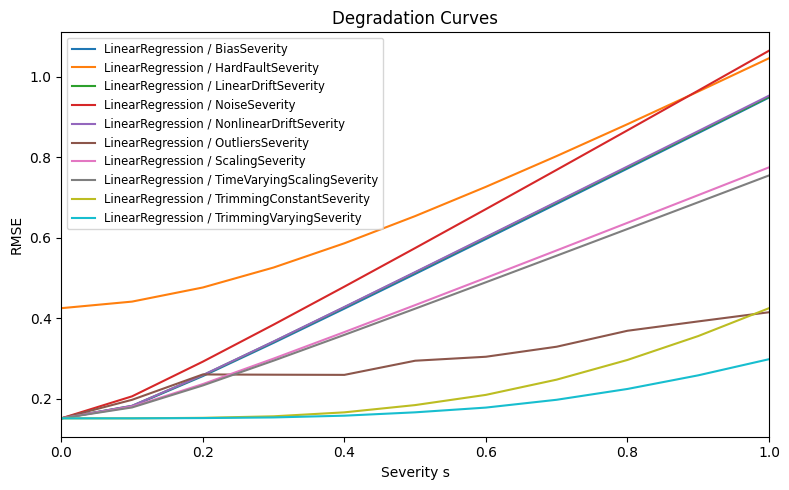

<Axes: title={'center': 'Degradation Curves'}, xlabel='Severity s', ylabel='RMSE'>

In [9]:
# Degradation curve: u_rel(s) averaged over features
results.plot_degradation(model="LinearRegression", show=True)

## 8. Export

Save the raw per-severity DataFrame to CSV.

In [10]:
results.to_csv("./results_quickstart")

Results saved to results_quickstart/
  per_severity.csv  (1100 rows)
